# 01. Análise Exploratória de Dados (EDA) & Qualidade
Este notebook importa o parser de `src/data_loader.py` para inspecionar a distribuição de expressão e estrutura dos metadados.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importa a funcao do nosso modulo src
sys.path.append(os.path.abspath('../src'))
from data_loader import parse_geo_series_matrix

raw_path = '../data/raw/GSE68849_series_matrix.txt.gz'
expr_df, meta_df = parse_geo_series_matrix(raw_path)

print('Dimensao Expressao:', expr_df.shape)
print('Dimensao Metadados:', meta_df.shape)

Dimensao Expressao: (47321, 10)
Dimensao Metadados: (10, 3)


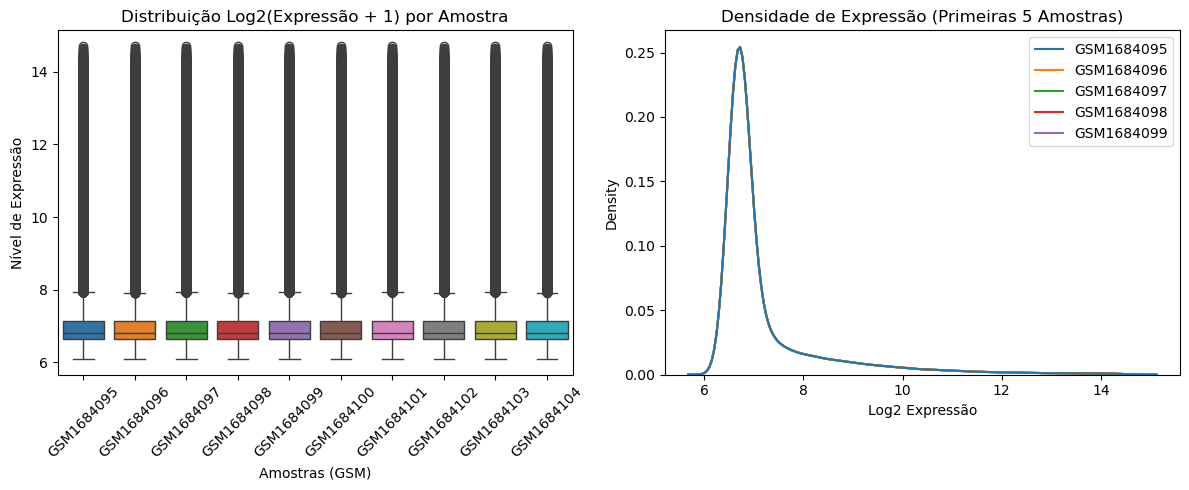

In [2]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=np.log2(expr_df + 1))
plt.title("Distribuição Log2(Expressão + 1) por Amostra")
plt.xlabel("Amostras (GSM)")
plt.ylabel("Nível de Expressão")
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.kdeplot(data=np.log2(expr_df + 1).iloc[:, :5])
plt.title("Densidade de Expressão (Primeiras 5 Amostras)")
plt.xlabel("Log2 Expressão")

plt.tight_layout()
plt.show()


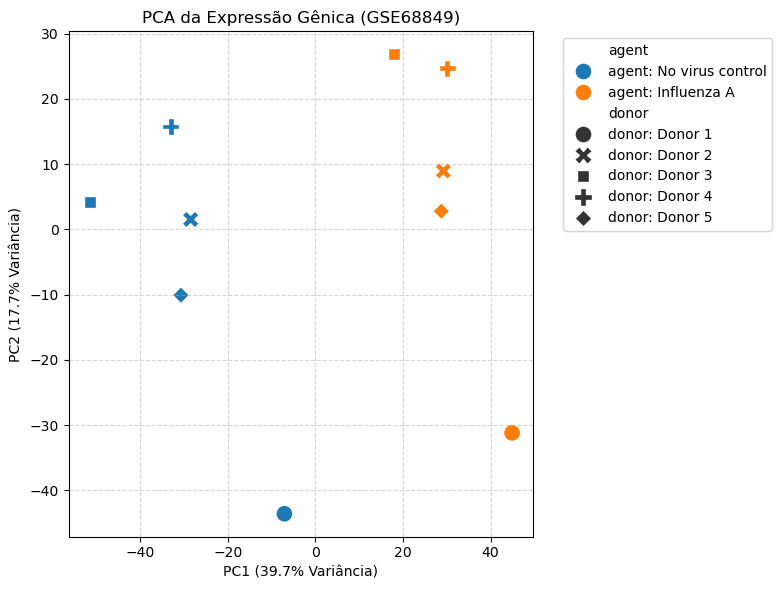

In [3]:
from sklearn.decomposition import PCA

# Transpõe a matriz para ter Amostras nas linhas e Genes nas colunas
X = np.log2(expr_df + 1).T

# Aplica PCA para reduzir para 2 componentes principais
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Cria DataFrame com os resultados do PCA e metadados
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'], index=X.index)
pca_df['agent'] = meta_df['agent'].values
pca_df['donor'] = meta_df['donor'].values

# Percentual da variância explicada
var_exp = pca.explained_variance_ratio_ * 100

# Plotagem do gráfico de PCA
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df, 
    x='PC1', 
    y='PC2', 
    hue='agent', 
    style='donor', 
    s=150
)

plt.title("PCA da Expressão Gênica (GSE68849)")
plt.xlabel(f"PC1 ({var_exp[0]:.1f}% Variância)")
plt.ylabel(f"PC2 ({var_exp[1]:.1f}% Variância)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()